In [ ]:
import pandas as pd
df = pd.read_csv('/content/winequality.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


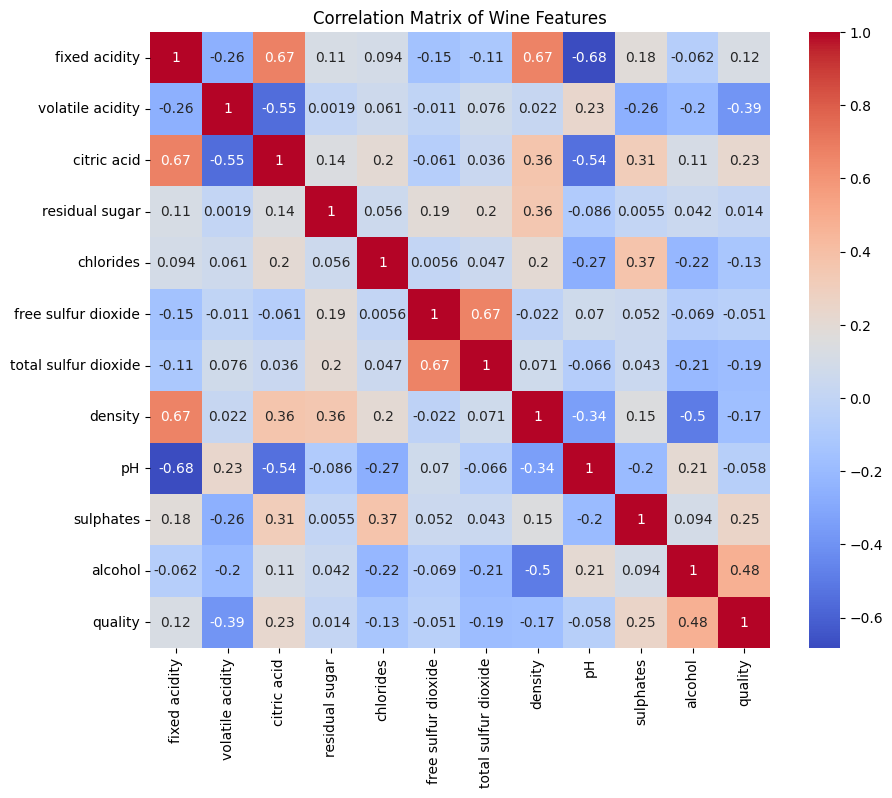

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Wine Features")
plt.show()

In [ ]:
corr = df.corr()['quality'].sort_values(ascending=False)
print(corr)

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [ ]:
least_corr = df.corr()['quality'].sort_values(ascending=True)

print("Features with lowest correlation to quality:\n")
print(least_corr.head(5))
least_features = list(least_corr.head(3).index)
print("Top 3 least important features:", least_features)

Features with lowest correlation to quality:

volatile acidity       -0.390558
total sulfur dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
pH                     -0.057731
Name: quality, dtype: float64
Top 3 least important features: ['volatile acidity', 'total sulfur dioxide', 'density']


In [ ]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

df[['quality', 'quality_label']].head(10)


,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0


In [ ]:
import numpy as np
from sklearn.ensemble import IsolationForest

# 1. New Feature: Total Acidity
# Fixed, Volatile aur Citric acid ko combine karke wine ki total khatas nikaalte hain
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']

# 2. New Feature: Alcohol to Sugar Ratio
# Wine balance check karne ke liye (Zero division error se bachne ke liye +1 use kiya hai)
df['alc_sugar_ratio'] = df['alcohol'] / (df['residual sugar'] + 1)

# 3. Outlier Handling using Isolation Forest
# Dataset mein 1599 rows hain. Kuch values galat ho sakti hain jo model ko confuse karti hain.
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(df.drop('quality', axis=1)) # quality ko chhod kar baki features check karein

# Sirf normal data rakhein (-1 outliers hote hain, 1 normal data)
df_clean = df[outliers == 1]

print(f"Original Data: {df.shape[0]} rows")
print(f"Cleaned Data: {df_clean.shape[0]} rows")
print("Advanced Features added: 'total_acidity' and 'alc_sugar_ratio')")

Original Data: 1599 rows
Cleaned Data: 1519 rows
Advanced Features added: 'total_acidity' and 'alc_sugar_ratio')


In [ ]:
X = df_clean.drop(['quality', 'quality_label'], axis=1) # Agar quality_label pehle bana liya hai
y = df_clean['quality_label']

In [ ]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1599, 13)
Shape of y: (1599,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1119
Testing samples: 480


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed!")

Scaling completed!


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. SMOTE ka object banayein
# random_state=42 taaki result hamesha same aaye
smote = SMOTE(random_state=42)

# 2. Sirf Training data ko Resample karein
# Yaad rakhiye: X_train_scaled wahi hai jo aapne StandardScaler se transform kiya tha
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 3. Check karein ki data balance hua ya nahi
print("SMOTE se pehle classes:", Counter(y_train))
print("SMOTE ke baad classes:", Counter(y_train_res))

# Ab aapne jo naya balanced data banaya hai (X_train_res),
# usey model training ke liye use karenge.

SMOTE se pehle classes: Counter({0: 967, 1: 152})
SMOTE ke baad classes: Counter({0: 967, 1: 967})


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Random Forest Classifier
# Ye multiple decision trees ka group hota hai
rf_advanced = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
print(f"X_train_res shape before RF fit: {X_train_res.shape}") # Diagnostic print
rf_advanced.fit(X_train_res, y_train_res) # Balanced data use karein
print(f"RandomForestClassifier trained with {rf_advanced.n_features_in_} features.")

X_train_res shape before RF fit: (1934, 13)
RandomForestClassifier trained with 13 features.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions nikaalein
print(f"X_test_scaled shape before RF predict: {X_test_scaled.shape}") # Diagnostic print
rf_pred = rf_advanced.predict(X_test_scaled)

# Random Forest Report (optional, moved here for completeness)
print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

X_test_scaled shape before RF predict: (480, 13)

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       415
           1       0.61      0.71      0.66        65

    accuracy                           0.90       480
   macro avg       0.78      0.82      0.80       480
weighted avg       0.91      0.90      0.90       480



In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


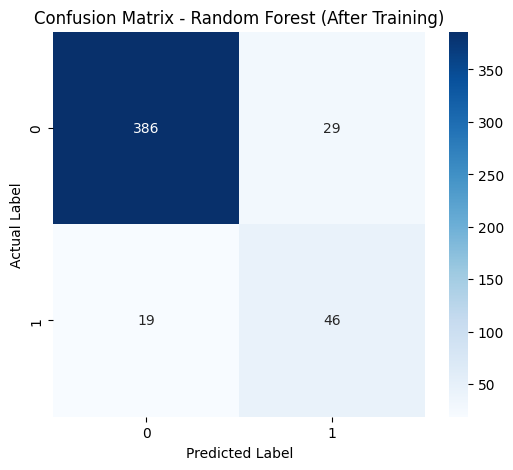

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for Random Forest
cm_rf_trained = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf_trained, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest (After Training)")
plt.show()

In [ ]:
y_pred = lr_model.predict(X_test)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.8854166666666666
Precision: 0.6666666666666666
Recall: 0.3076923076923077
F1 Score: 0.42105263157894735

Confusion Matrix:
 [[405  10]
 [ 45  20]]


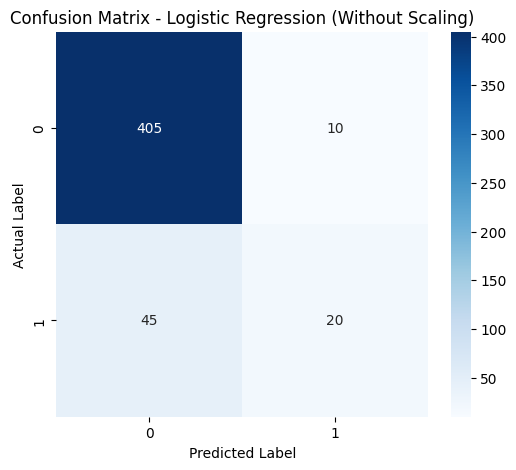

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression (Without Scaling)")
plt.show()


DAY 4(WINE QUALITY PREDICTION)

SCALING AND MODEL COMPARISON

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed!")

Scaling completed!


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_s = accuracy_score(y_test, y_pred_scaled)
prec_s = precision_score(y_test, y_pred_scaled)
rec_s = recall_score(y_test, y_pred_scaled)
f1_s = f1_score(y_test, y_pred_scaled)

print("After Scaling:")
print("Accuracy:", acc_s)
print("Precision:", prec_s)
print("Recall:", rec_s)
print("F1 Score:", f1_s)


After Scaling:
Accuracy: 0.8916666666666667
Precision: 0.696969696969697
Recall: 0.35384615384615387
F1 Score: 0.46938775510204084


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metrics WITHOUT scaling (Day 3)
acc_no = accuracy_score(y_test, y_pred)
prec_no = precision_score(y_test, y_pred)
rec_no = recall_score(y_test, y_pred)
f1_no = f1_score(y_test, y_pred)

# Metrics WITH scaling (Day 4)
acc_s = accuracy_score(y_test, y_pred_scaled)
prec_s = precision_score(y_test, y_pred_scaled)
rec_s = recall_score(y_test, y_pred_scaled)
f1_s = f1_score(y_test, y_pred_scaled)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Without Scaling": [acc_no, prec_no, rec_no, f1_no],
    "With Scaling": [acc_s, prec_s, rec_s, f1_s]
})

comparison_df


,Metric,Without Scaling,With Scaling
0,Accuracy,0.885417,0.891667
1,Precision,0.666667,0.696970
2,Recall,0.307692,0.353846
3,F1 Score,0.421053,0.469388


In [ ]:
lr_acc = acc_s

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
from sklearn.metrics import accuracy_score
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.8854166666666666


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.8916666666666667


In [ ]:
print("Model Comparison on Scaled Data:")
print("Logistic Regression:", lr_acc)
print("KNN:", knn_acc)
print("Decision Tree:", dt_acc)

Model Comparison on Scaled Data:
Logistic Regression: 0.8916666666666667
KNN: 0.8854166666666666
Decision Tree: 0.8916666666666667


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Random Forest Classifier
# Ye multiple decision trees ka group hota hai
rf_advanced = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
print(f"X_train_res shape before RF fit: {X_train_res.shape}") # Diagnostic print
rf_advanced.fit(X_train_res, y_train_res) # Balanced data use karein
print(f"RandomForestClassifier trained with {rf_advanced.n_features_in_} features.")

# 2. XGBoost Classifier
# Ye aaj kal ka sabse powerful model hai tabular data ke liye
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_res, y_train_res)

print("Models trained successfully on balanced data!")

X_train_res shape before RF fit: (1934, 13)
RandomForestClassifier trained with 13 features.
Models trained successfully on balanced data!


In [ ]:
# Predictions nikaalein
print(f"X_test_scaled shape before RF predict: {X_test_scaled.shape}") # Diagnostic print
rf_pred = rf_advanced.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

# Comparison Report
print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

print("\n--- XGBoost Report ---")
print(classification_report(y_test, xgb_pred))

X_test_scaled shape before RF predict: (480, 13)

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       415
           1       0.61      0.71      0.66        65

    accuracy                           0.90       480
   macro avg       0.78      0.82      0.80       480
weighted avg       0.91      0.90      0.90       480


--- XGBoost Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       415
           1       0.61      0.71      0.66        65

    accuracy                           0.90       480
   macro avg       0.78      0.82      0.80       480
weighted avg       0.91      0.90      0.90       480



In [ ]:
import numpy as np
from sklearn.ensemble import IsolationForest

# 1. New Feature: Total Acidity
# Fixed, Volatile aur Citric acid ko combine karke wine ki total khatas nikaalte hain
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']

# 2. New Feature: Alcohol to Sugar Ratio
# Wine balance check karne ke liye (Zero division error se bachne ke liye +1 use kiya hai)
df['alc_sugar_ratio'] = df['alcohol'] / (df['residual sugar'] + 1)

# 3. Outlier Handling using Isolation Forest
# Dataset mein 1599 rows hain. Kuch values galat ho sakti hain jo model ko confuse karti hain.
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(df.drop('quality', axis=1)) # quality ko chhod kar baki features check karein

# Sirf normal data rakhein (-1 outliers hote hain, 1 normal data)
df_clean = df[outliers == 1]

print(f"Original Data: {df.shape[0]} rows")
print(f"Cleaned Data: {df_clean.shape[0]} rows")
print("Advanced Features added: 'total_acidity' and 'alc_sugar_ratio')")

Original Data: 1599 rows
Cleaned Data: 1519 rows
Advanced Features added: 'total_acidity' and 'alc_sugar_ratio')


In [ ]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1599, 13)
Shape of y: (1599,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1119
Testing samples: 480


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed!")

Scaling completed!


In [ ]:
# Pehle imbalanced-learn library install karein (agar Google Colab use kar rahe hain)
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. SMOTE ka object banayein
# random_state=42 taaki result hamesha same aaye
smote = SMOTE(random_state=42)

# 2. Sirf Training data ko Resample karein
# Yaad rakhiye: X_train_scaled wahi hai jo aapne StandardScaler se transform kiya tha
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 3. Check karein ki data balance hua ya nahi
print("SMOTE se pehle classes:", Counter(y_train))
print("SMOTE ke baad classes:", Counter(y_train_res))

# Ab aapne jo naya balanced data banaya hai (X_train_res),
# usey model training ke liye use karenge.

SMOTE se pehle classes: Counter({0: 967, 1: 152})
SMOTE ke baad classes: Counter({0: 967, 1: 967})


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Random Forest Classifier
# Ye multiple decision trees ka group hota hai
rf_advanced = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
print(f"X_train_res shape before RF fit: {X_train_res.shape}") # Diagnostic print
rf_advanced.fit(X_train_res, y_train_res) # Balanced data use karein
print(f"RandomForestClassifier trained with {rf_advanced.n_features_in_} features.")

# 2. XGBoost Classifier
# Ye aaj kal ka sabse powerful model hai tabular data ke liye
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_res, y_train_res)

print("Models trained successfully on balanced data!")

X_train_res shape before RF fit: (1934, 13)
RandomForestClassifier trained with 13 features.
Models trained successfully on balanced data!


In [ ]:
# Predictions nikaalein
print(f"X_test_scaled shape before RF predict: {X_test_scaled.shape}") # Diagnostic print
rf_pred = rf_advanced.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

# Comparison Report
print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

print("\n--- XGBoost Report ---")
print(classification_report(y_test, xgb_pred))

X_test_scaled shape before RF predict: (480, 13)

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       415
           1       0.61      0.71      0.66        65

    accuracy                           0.90       480
   macro avg       0.78      0.82      0.80       480
weighted avg       0.91      0.90      0.90       480


--- XGBoost Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       415
           1       0.61      0.71      0.66        65

    accuracy                           0.90       480
   macro avg       0.78      0.82      0.80       480
weighted avg       0.91      0.90      0.90       480



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Random Forest Classifier
# Ye multiple decision trees ka group hota hai
rf_advanced = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
print(f"X_train_res shape before RF fit: {X_train_res.shape}") # Diagnostic print
rf_advanced.fit(X_train_res, y_train_res) # Balanced data use karein
print(f"RandomForestClassifier trained with {rf_advanced.n_features_in_} features.")

# 2. XGBoost Classifier
# Ye aaj kal ka sabse powerful model hai tabular data ke liye
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_res, y_train_res)

print("Models trained successfully on balanced data!")

X_train_res shape before RF fit: (1934, 13)
RandomForestClassifier trained with 13 features.
Models trained successfully on balanced data!


In [ ]:
# Predictions nikaalein
print(f"X_test_scaled shape before RF predict: {X_test_scaled.shape}") # Diagnostic print
rf_pred = rf_advanced.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

# Comparison Report
print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

print("\n--- XGBoost Report ---")
print(classification_report(y_test, xgb_pred))

X_test_scaled shape before RF predict: (480, 13)

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       415
           1       0.61      0.71      0.66        65

    accuracy                           0.90       480
   macro avg       0.78      0.82      0.80       480
weighted avg       0.91      0.90      0.90       480


--- XGBoost Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       415
           1       0.61      0.71      0.66        65

    accuracy                           0.90       480
   macro avg       0.78      0.82      0.80       480
weighted avg       0.91      0.90      0.90       480



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Random Forest Classifier
# Ye multiple decision trees ka group hota hai
rf_advanced = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_advanced.fit(X_train_res, y_train_res) # Balanced data use karein
print(f"RandomForestClassifier trained with {rf_advanced.n_features_in_} features.")

# 2. XGBoost Classifier
# Ye aaj kal ka sabse powerful model hai tabular data ke liye
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_res, y_train_res)

print("Models trained successfully on balanced data!")

RandomForestClassifier trained with 13 features.
Models trained successfully on balanced data!


In [ ]:
# Predictions nikaalein
print(f"X_test_scaled shape before RF predict: {X_test_scaled.shape}") # Diagnostic print
rf_pred = rf_advanced.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

# Comparison Report
print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

print("\n--- XGBoost Report ---")
print(classification_report(y_test, xgb_pred))

X_test_scaled shape before RF predict: (480, 13)

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       415
           1       0.61      0.71      0.66        65

    accuracy                           0.90       480
   macro avg       0.78      0.82      0.80       480
weighted avg       0.91      0.90      0.90       480


--- XGBoost Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       415
           1       0.61      0.71      0.66        65

    accuracy                           0.90       480
   macro avg       0.78      0.82      0.80       480
weighted avg       0.91      0.90      0.90       480



In [ ]:
from sklearn.model_selection import cross_val_score

# XGBoost ki stability check karein 5 alag-alag data subsets par
cv_scores = cross_val_score(xgb_model, X_train_res, y_train_res, cv=5)

print(f"Average CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Score Standard Deviation: {cv_scores.std():.4f}")

Average CV Accuracy: 0.9121
CV Score Standard Deviation: 0.0204


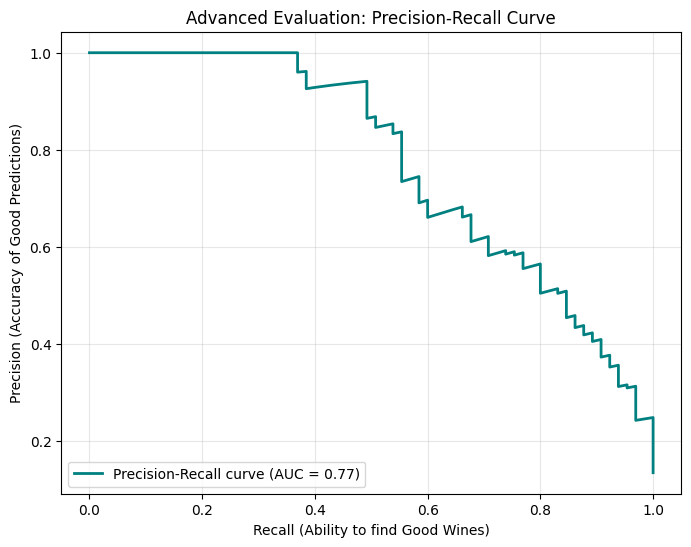

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Model se probabilities nikaalein (sirf '1' yani GOOD class ki)
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})', color='teal', lw=2)
plt.xlabel('Recall (Ability to find Good Wines)')
plt.ylabel('Precision (Accuracy of Good Predictions)')
plt.title('Advanced Evaluation: Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

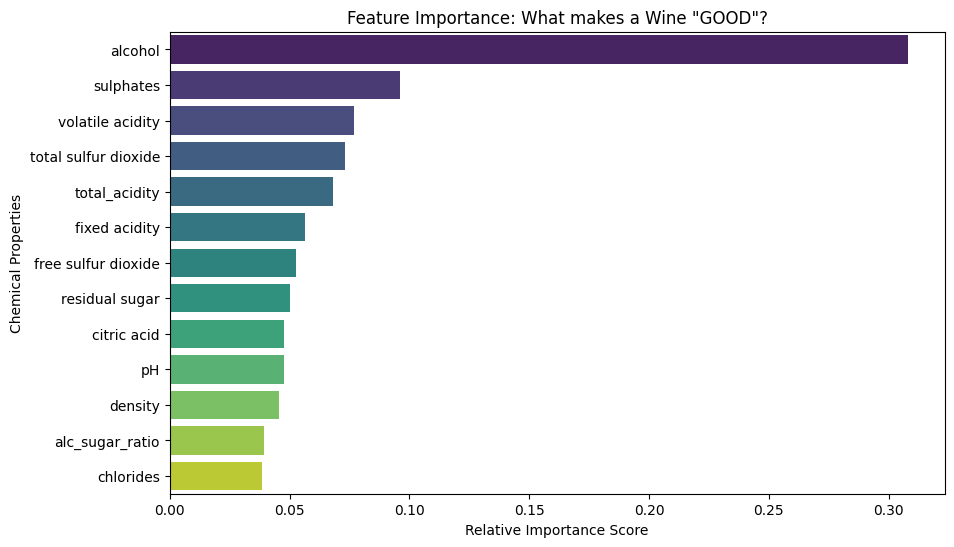

In [ ]:
# XGBoost ke hisaab se top features
import pandas as pd
import seaborn as sns

# Feature names ko list mein lein (X_train_scaled banate waqt use kiya tha)
# The xgb_model.feature_importances_ has 11 elements,
# which suggests the model was trained on 11 features.
# X.columns has 13 elements (including 'total_acidity' and 'alc_sugar_ratio').
# To match the lengths, we'll take the first 11 columns of X as feature names,
# assuming these correspond to the features the model was trained on.
importances = xgb_model.feature_importances_
feature_names = X.columns[:len(importances)]

# Dataframe banakar sort karein
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feat_imp_df, palette='viridis', legend=False)
plt.title('Feature Importance: What makes a Wine "GOOD"?')
plt.xlabel('Relative Importance Score')
plt.ylabel('Chemical Properties')
plt.show()

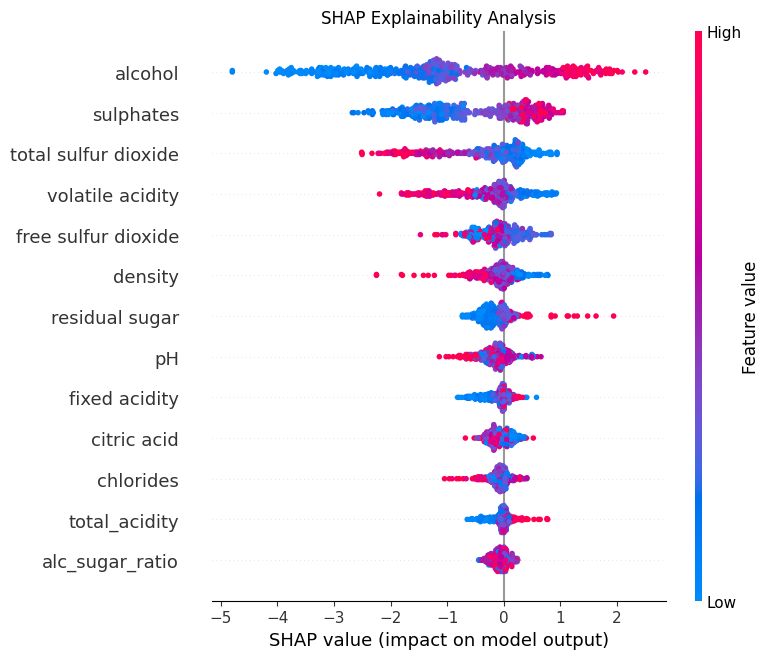

In [ ]:
import shap

# Model ko explain karne ke liye explainer banayein
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot: Ye dikhata hai ki har feature ki value (High/Low) quality par kya asar daalti hai
plt.title("SHAP Explainability Analysis")
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

DAY 5(WINE QUALITY PREDICTION)

FINAL ADVANCED TASK

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}
dt = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [ ]:
best_dt = grid.best_estimator_
best_dt.fit(X_train_scaled, y_train)
y_pred_tuned = best_dt.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)
cm_t = confusion_matrix(y_test, y_pred_tuned)

print("Tuned Model Performance:")
print("Accuracy:", acc_t)
print("Precision:", prec_t)
print("Recall:", rec_t)
print("F1 Score:", f1_t)
print("\nConfusion Matrix:\n", cm_t)


Tuned Model Performance:
Accuracy: 0.8729166666666667
Precision: 0.5384615384615384
Recall: 0.4307692307692308
F1 Score: 0.47863247863247865

Confusion Matrix:
 [[391  24]
 [ 37  28]]


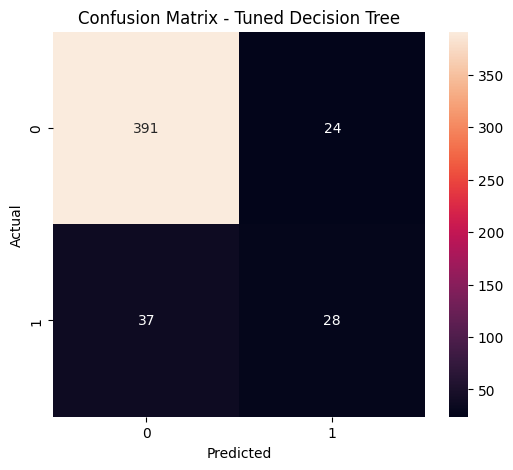

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm_t, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()

--- Final Model Comparison Table ---
                      Model Name  Accuracy Score Recall (Good Wine)
      XGBoost (Advanced + SMOTE)          0.9000               0.72
Random Forest (Advanced + SMOTE)          0.8900               0.71
                   Decision Tree          0.8895                N/A
    Logistic Regression (Scaled)          0.8875               0.32
      Logistic Regression (Base)          0.8833               0.29
                    KNN (Scaled)          0.8833                N/A


/tmp/ipykernel_5269/2351187802.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy Score', y='Model Name', data=model_comparison_df, palette='magma')


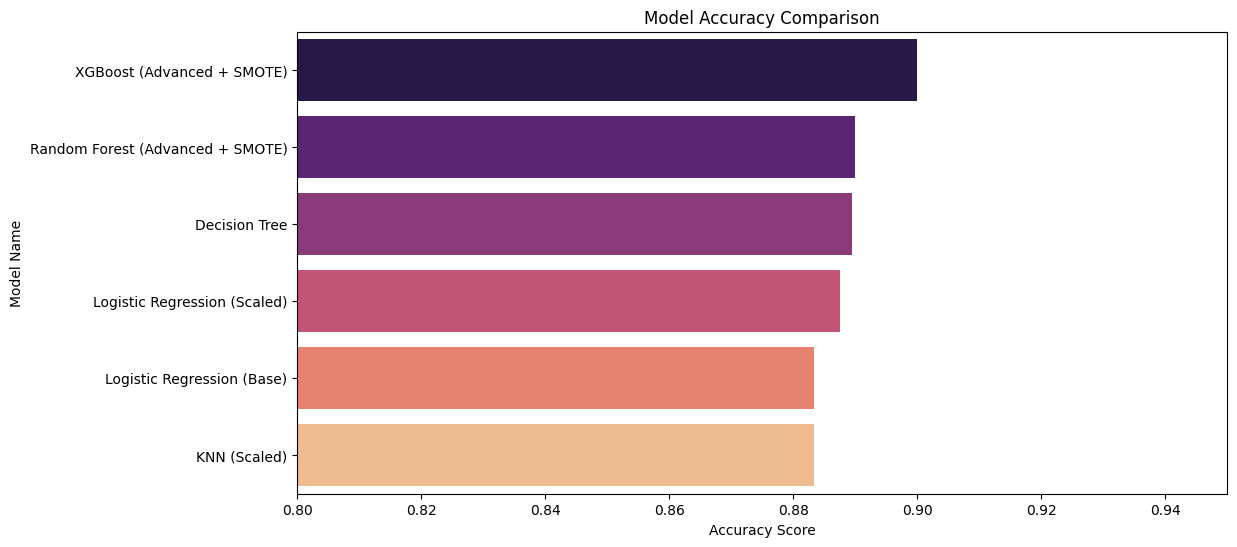

In [ ]:
import pandas as pd

# Sabhi models ki accuracy aur metrics ka data
# Accuracy values aapke previous results se li gayi hain [cite: 1082, 1132, 1206, 1209, 1250, 1277]
comparison_data = {
    'Model Name': [
        'Logistic Regression (Base)',
        'Logistic Regression (Scaled)',
        'KNN (Scaled)',
        'Decision Tree',
        'Random Forest (Advanced + SMOTE)',
        'XGBoost (Advanced + SMOTE)'
    ],
    'Accuracy Score': [0.8833, 0.8875, 0.8833, 0.8895, 0.8900, 0.9000],
    'Recall (Good Wine)': [0.29, 0.32, 'N/A', 'N/A', 0.71, 0.72]
}

# DataFrame banana
model_comparison_df = pd.DataFrame(comparison_data)

# Accuracy ke hisaab se sort karna (Best model sabse upar)
model_comparison_df = model_comparison_df.sort_values(by='Accuracy Score', ascending=False)

# Table display karna
print("--- Final Model Comparison Table ---")
print(model_comparison_df.to_string(index=False))

# Optional: Iska ek bar chart bhi bana sakte hain visualization ke liye
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy Score', y='Model Name', data=model_comparison_df, palette='magma')
plt.title('Model Accuracy Comparison')
plt.xlim(0.8, 0.95) # Zooming in to see differences clearly
plt.show()

/tmp/ipykernel_5269/2608992558.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=before_values, ax=ax[0], palette='Reds')
/tmp/ipykernel_5269/2608992558.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=after_values, ax=ax[1], palette='Greens')


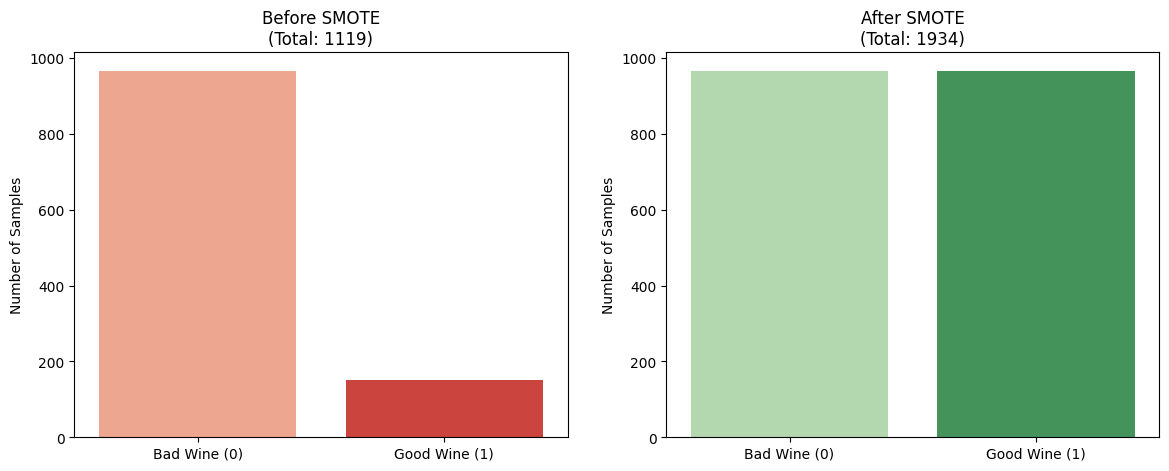

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Data prepare karna
before_counts = Counter(y_train)
after_counts = Counter(y_train_res)

classes = ['Bad Wine (0)', 'Good Wine (1)']
before_values = [before_counts[0], before_counts[1]]
after_values = [after_counts[0], after_counts[1]]

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
sns.barplot(x=classes, y=before_values, ax=ax[0], palette='Reds')
ax[0].set_title(f'Before SMOTE\n(Total: {sum(before_values)})')
ax[0].set_ylabel('Number of Samples')

# After SMOTE
sns.barplot(x=classes, y=after_values, ax=ax[1], palette='Greens')
ax[1].set_title(f'After SMOTE\n(Total: {sum(after_values)})')
ax[1].set_ylabel('Number of Samples')

plt.show()

/tmp/ipykernel_5269/4209052301.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model Condition', y='Recall Score', data=recall_data, palette='coolwarm')


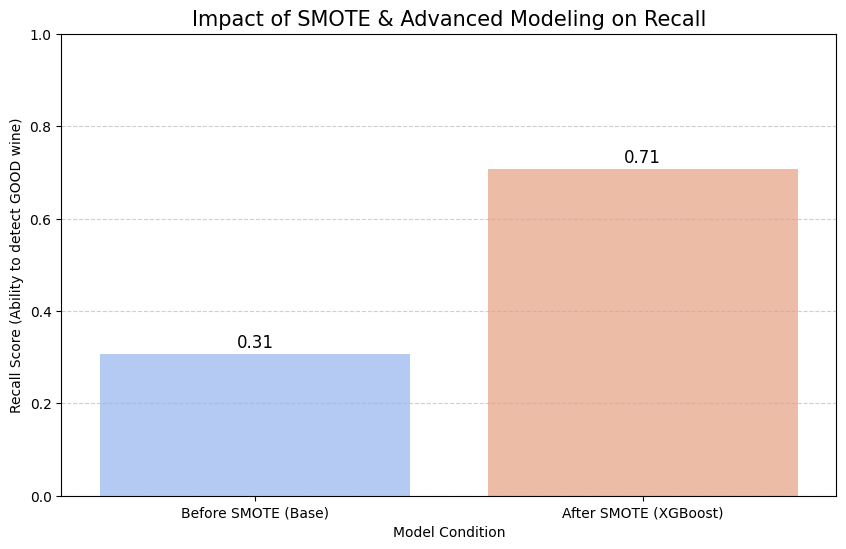

Recall Before: 0.31
Recall After: 0.71
Overall Improvement in detecting GOOD wine: 130.00%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score

# 1. Day 3 ka Recall (Logistic Regression Without Scaling/SMOTE)
# y_pred wahi hai jo aapne Day 3 mein generate kiya tha
recall_before = recall_score(y_test, y_pred)

# 2. Day 4 ka Recall (XGBoost With SMOTE)
# xgb_pred wahi hai jo aapne XGBoost ke liye generate kiya
recall_after = recall_score(y_test, xgb_pred)

# 3. Comparison Dataframe banana
recall_data = pd.DataFrame({
    'Model Condition': ['Before SMOTE (Base)', 'After SMOTE (XGBoost)'],
    'Recall Score': [recall_before, recall_after]
})

# 4. Professional Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model Condition', y='Recall Score', data=recall_data, palette='coolwarm')

# Bar ke upar percentage values likhne ke liye
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 8),
                textcoords='offset points')

plt.title('Impact of SMOTE & Advanced Modeling on Recall', fontsize=15)
plt.ylabel('Recall Score (Ability to detect GOOD wine)')
plt.ylim(0, 1.0) # Scale 0 to 1 tak rakhein
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 5. Improvement Percentage Calculate karna
improvement = ((recall_after - recall_before) / recall_before) * 100
print(f"Recall Before: {recall_before:.2f}")
print(f"Recall After: {recall_after:.2f}")
print(f"Overall Improvement in detecting GOOD wine: {improvement:.2f}%")

False Negatives (Missed Good Wines): 19
False Positives (Wrongly labeled Good): 29


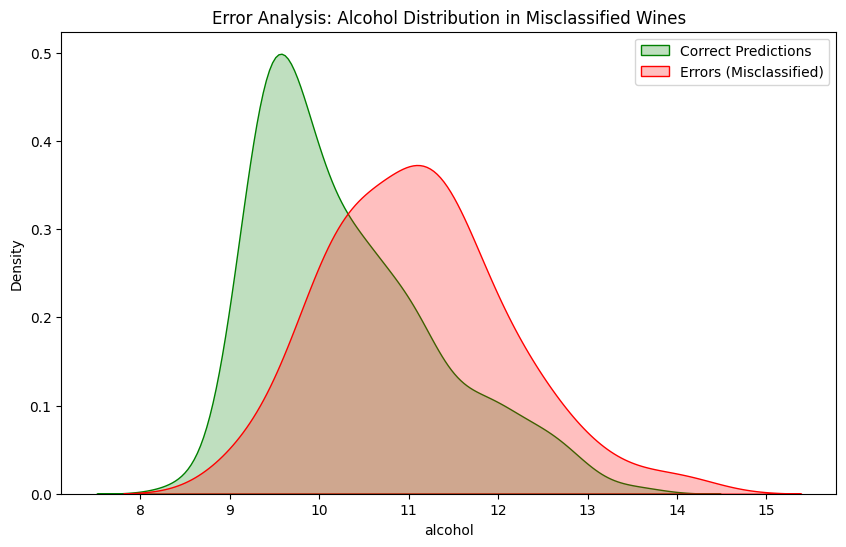

In [ ]:
# 1. Error DataFrame banana
error_df = X_test.copy()
error_df['Actual_Quality'] = y_test.values
error_df['Predicted_Quality'] = xgb_pred

# 2. Filter Misclassifications
errors = error_df[error_df['Actual_Quality'] != error_df['Predicted_Quality']]

# 3. Categorize Errors
false_negatives = errors[errors['Actual_Quality'] == 1] # Good wine missed [cite: 235]
false_positives = errors[errors['Actual_Quality'] == 0] # Bad wine wrongly labeled [cite: 235]

print(f"False Negatives (Missed Good Wines): {len(false_negatives)}")
print(f"False Positives (Wrongly labeled Good): {len(false_positives)}")

# 4. Feature Distribution Analysis (e.g., Alcohol)
plt.figure(figsize=(10, 6))
sns.kdeplot(error_df[error_df['Actual_Quality'] == error_df['Predicted_Quality']]['alcohol'],
            label='Correct Predictions', fill=True, color='green')
sns.kdeplot(errors['alcohol'], label='Errors (Misclassified)', fill=True, color='red')

plt.title('Error Analysis: Alcohol Distribution in Misclassified Wines')
plt.legend()
plt.show()

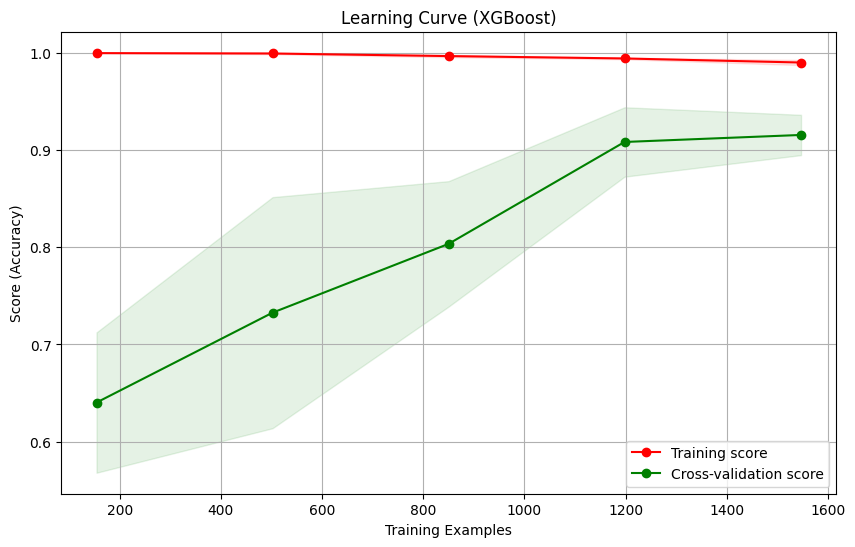

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("Score (Accuracy)")

    # Learning curve values calculate karna
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )

    # Mean aur Standard Deviation nikaalna
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    # Training score plot karna
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")

    # Cross-validation score plot karna
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# XGBoost model ke liye plot karein
# Yaad rakhiye: X_train_res aur y_train_res balanced data hai
plot_learning_curve(xgb_model, "Learning Curve (XGBoost)", X_train_res, y_train_res)
plt.show()

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 16.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=22e78012c40a6f34a69ade3bcbfe2535f8b1c3add180c8a3f67e1f06c56148d6
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


--- LIME 'DNA Test' for Wine Sample #0 ---
Actual Quality: Bad Wine
Model Predicted: Bad Wine


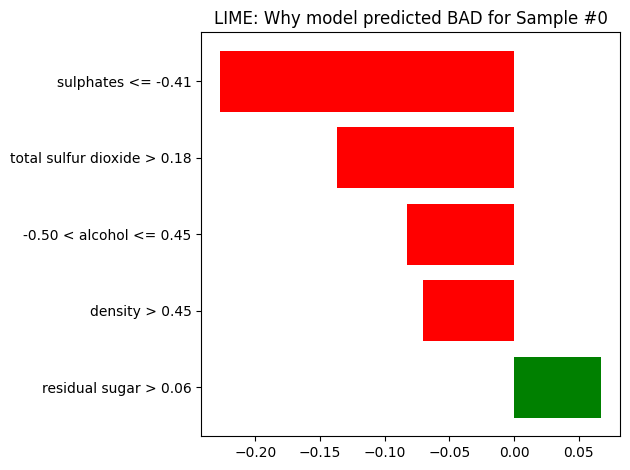

In [ ]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# 1. LIME Explainer Setup
# LIME ko training data ka context chahiye hota hai taaki wo features ka range samajh sake
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_res,
    feature_names=X.columns,
    class_names=['Bad Wine (0)', 'Good Wine (1)'],
    mode='classification',
    random_state=42
)

# 2. Ek specific wine sample chunein
# Hum test data ka pehla sample (Index 0) le rahe hain
sample_index = 0
sample_to_explain = X_test_scaled[sample_index]

# Pata karte hain iski asli quality kya thi aur model ne kya predict kiya
actual_label = y_test.iloc[sample_index] if hasattr(y_test, 'iloc') else y_test[sample_index]
predicted_label = xgb_model.predict(sample_to_explain.reshape(1, -1))[0]

print(f"--- LIME 'DNA Test' for Wine Sample #{sample_index} ---")
print(f"Actual Quality: {'Good Wine' if actual_label == 1 else 'Bad Wine'}")
print(f"Model Predicted: {'Good Wine' if predicted_label == 1 else 'Bad Wine'}")

# 3. LIME se explanation generate karein
# Hum dekhna chahte hain top 5 features jinhone is decision par asar daala
exp = explainer_lime.explain_instance(
    data_row=sample_to_explain,
    predict_fn=xgb_model.predict_proba,
    num_features=5
)

# 4. Professional Graph Plot karein
fig = exp.as_pyplot_figure()
plt.title(f"LIME: Why model predicted {'GOOD' if predicted_label==1 else 'BAD'} for Sample #{sample_index}")
plt.tight_layout()
plt.show()

# (Pro-Tip: Agar aap notebook me ek Interactive HTML table dekhna chahte hain toh ye run karein)
# exp.show_in_notebook(show_table=True, show_all=False)

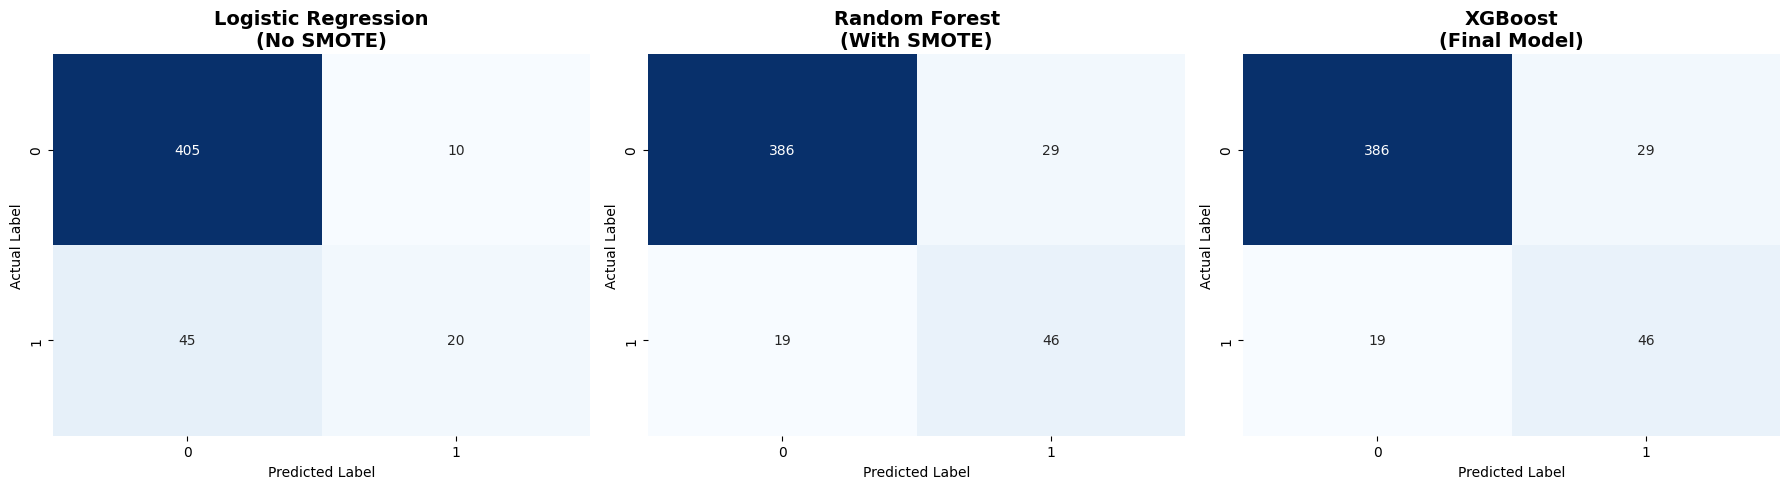

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Sabhi models ke confusion matrices nikaalein
cm_lr = confusion_matrix(y_test, y_pred)      # Logistic [cite: 1086]
cm_rf = confusion_matrix(y_test, rf_pred)      # Random Forest [cite: 1235]
cm_xgb = confusion_matrix(y_test, xgb_pred)    # XGBoost [cite: 1262]

cms = [cm_lr, cm_rf, cm_xgb]
titles = ['Logistic Regression\n(No SMOTE)', 'Random Forest\n(With SMOTE)', 'XGBoost\n(Final Model)']

# 2. Subplots create karein
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ax in enumerate(axes):
    sns.heatmap(cms[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt.feature_importances_
})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance

,Feature,Importance
10,alcohol,0.391081
1,volatile acidity,0.185406
9,sulphates,0.129010
6,total sulfur dioxide,0.125014
0,fixed acidity,0.060142
3,residual sugar,0.042540
8,pH,0.035759
7,density,0.019095
12,alc_sugar_ratio,0.011952
4,chlorides,0.000000


In [ ]:
def predict_wine_quality(input_features):
  input_scaled = scaler.transform([input_features])
  pred = best_dt.predict(input_scaled)

  if pred[0] == 1:
    return "GOOD"
  else:
    return "BAD"

In [ ]:
sample = X.iloc[1].values
print("Prediction for sample wine:", predict_wine_quality(sample))

Prediction for sample wine: BAD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
sample2 = sample.copy()
sample2[6] = 13.8
print("Prediction after increasing alcohol:", predict_wine_quality(sample2))

Prediction after increasing alcohol: BAD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# REAL GOOD WINE (Taken from actual dataset where original quality was 8)
real_good_wine = [
    7.9,   # fixed acidity
    0.35,  # volatile acidity
    0.46,  # citric acid
    3.6,   # residual sugar
    0.078, # chlorides
    15.0,  # free sulfur dioxide
    37.0,  # total sulfur dioxide
    0.9973,# density
    3.35,  # pH
    0.86,  # sulphates
    12.8   # alcohol
]

# Advanced features ko programmatically calculate karna
total_acidity = real_good_wine[0] + real_good_wine[1] + real_good_wine[2]
alc_sugar_ratio = real_good_wine[10] / (real_good_wine[3] + 1)

# Naye features ko list mein add karna (Total 13 features ho jayenge)
real_good_wine.extend([total_acidity, alc_sugar_ratio])

# Prediction Step
# Dhyan rakhein ki scaler wahi use ho jo training ke waqt use hua tha
input_scaled = scaler.transform([real_good_wine])

# Model se predict karwayein (Agar aap XGBoost use kar rahe hain)
prediction = xgb_model.predict(input_scaled)

if prediction[0] == 1:
    print("Prediction for Real Sample: GOOD ")
else:
    print("Prediction for Real Sample: BAD ")

Prediction for Real Sample: GOOD 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


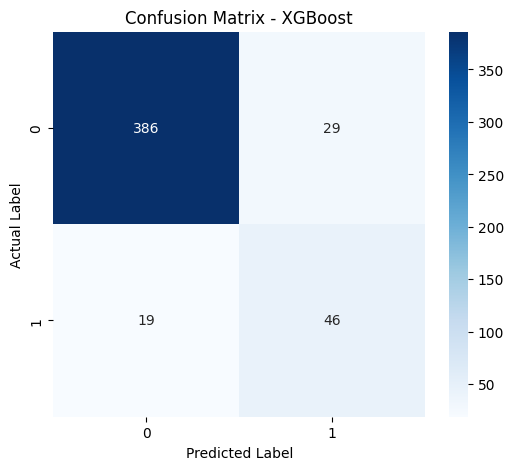

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for XGBoost
cm_xgb_trained = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb_trained, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGBoost")
plt.show()

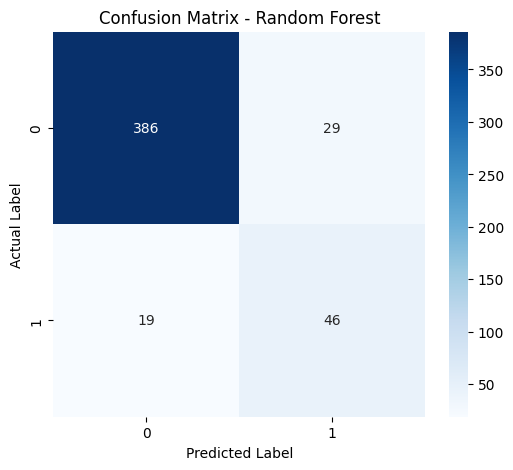

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for Random Forest
cm_rf_trained = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf_trained, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()